# 2.EDA
作成した記述子を説明変数として、目的変数の分布・相関・次元削減（PCA 等）でデータの様子を把握する。

---

## ユーザー設定（ここを編集してください）
**以下のセルで目的変数などを指定してください。1.Preparation.ipynb と同じ設定を使用します。**


## ライブラリ・データ読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# matplotlib のフォント設定を変更
plt.rcParams['font.family'] = 'sans-serif'

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.spatial.distance import cdist

In [ ]:
# ============================================================
# ユーザー設定: 1.Preparation.ipynb と同じ設定を使用
# ============================================================

# 目的変数の列名（リストで複数指定可能）
TARGET_COLS = ["Emission max (nm)", "Quantum yield"]

# 使用する記述子のタイプ
DESCRIPTOR_TYPE = "rdkit"  # "rdkit" or "mordred_2d" or "mordred_3d" or "fp"

# ============================================================
print(f"目的変数: {TARGET_COLS}")
print(f"記述子タイプ: {DESCRIPTOR_TYPE}")

In [2]:
# データ読み込み（設定変数を使用）

# ベースのデータ
dataset = pd.read_csv("../data/dataset_train.csv", index_col=0)

# 目的変数が揃っている行のみ
target = dataset[TARGET_COLS].dropna(how="any")

# 条件に応じて記述子ファイルを読み込む
if DESCRIPTOR_TYPE == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_2d":
    des = pd.read_csv("outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_3d":
    des = pd.read_csv("outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の DESCRIPTOR_TYPE: {DESCRIPTOR_TYPE}")

# 結合（目的変数 + 記述子）
dataset_train = target.join(des, how="inner")

print(f"target: {target.shape}, descriptors: {des.shape}, dataset_train: {dataset_train.shape}")


(13132, 2) (13132, 206) (13132, 208)


In [3]:
# 中身を確認
dataset_train.head()

,Emission max (nm),Quantum yield,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Tag,,,,,,,,,,,,,,,,,,,,,
72,538.0,0.200,12.408729,12.408729,0.029454,-1.347366,0.284676,11.310345,645.879,639.831,...,0,0,0,0,0,0,0,0,0,0
73,534.0,0.020,12.503623,12.503623,0.021975,-1.307991,0.220631,11.310345,833.879,827.831,...,0,0,0,0,0,0,0,0,0,0
74,566.0,0.018,12.637713,12.637713,0.057996,-1.632189,0.093205,11.515152,971.659,969.643,...,0,0,0,0,0,0,0,0,0,0
75,542.0,0.600,12.408729,12.408729,0.029454,-1.347366,0.284676,11.310345,645.879,639.831,...,0,0,0,0,0,0,0,0,0,0
76,545.0,0.080,12.503623,12.503623,0.021975,-1.307991,0.220631,11.310345,833.879,827.831,...,0,0,0,0,0,0,0,0,0,0


## 可視化

### Emission max（nm）


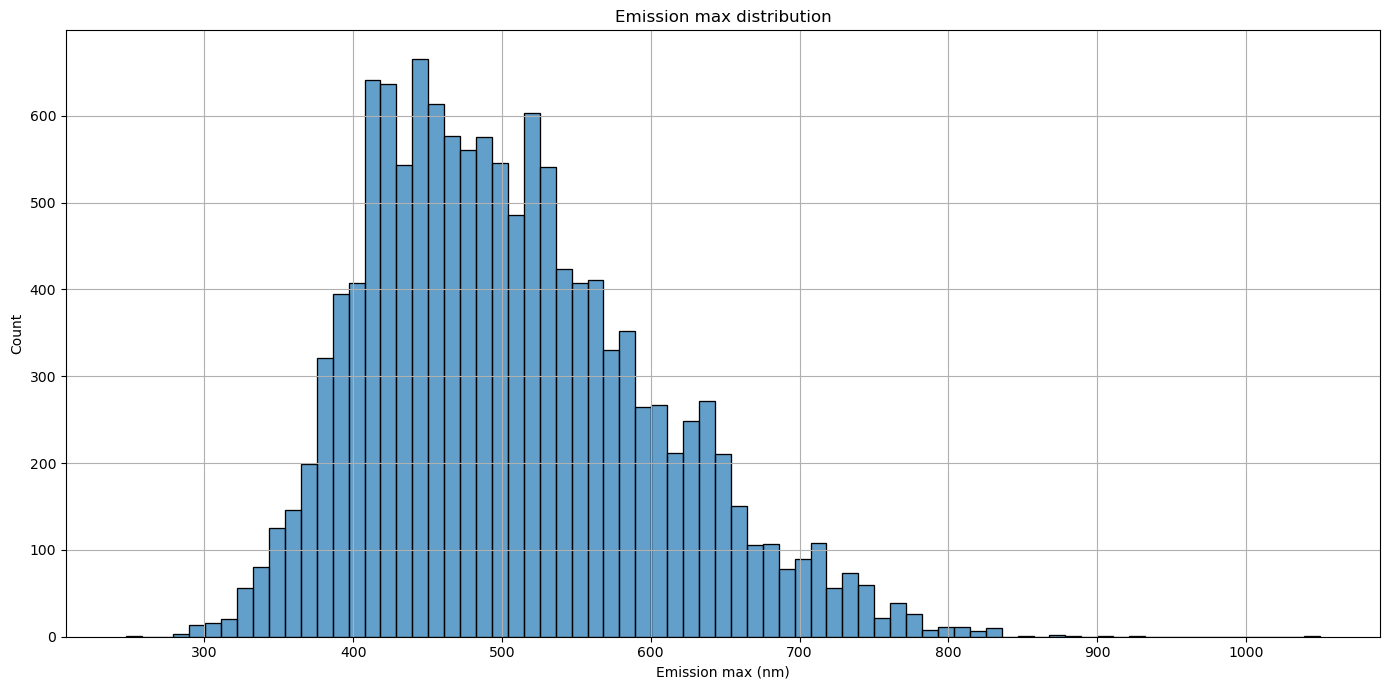

In [4]:
# 目的変数1の分布
plt.figure(figsize=(14, 7))
sns.histplot(data=dataset_train, x=TARGET_COLS[0], bins=75, alpha=0.7)

plt.xlabel(TARGET_COLS[0])
plt.ylabel("Count")
plt.title(f"{TARGET_COLS[0]} distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### Quantum yield（PLQY）


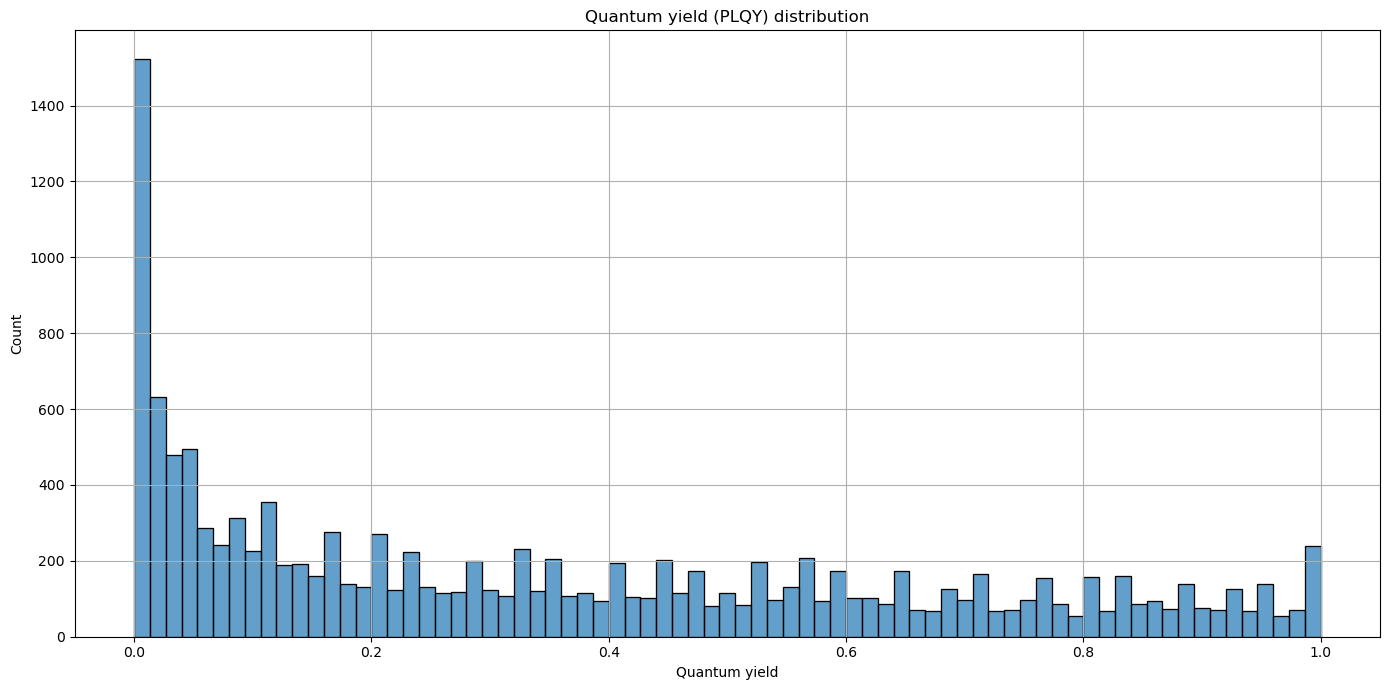

In [5]:
# 目的変数2の分布（TARGET_COLS に2つ以上ある場合）
if len(TARGET_COLS) >= 2:
    plt.figure(figsize=(14, 7))
    sns.histplot(data=dataset_train, x=TARGET_COLS[1], bins=75, alpha=0.7)

    plt.xlabel(TARGET_COLS[1])
    plt.ylabel("Count")
    plt.title(f"{TARGET_COLS[1]} distribution")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("目的変数が1つのみのため、スキップ")

### 記述子との相関の絶対値（Emission max）


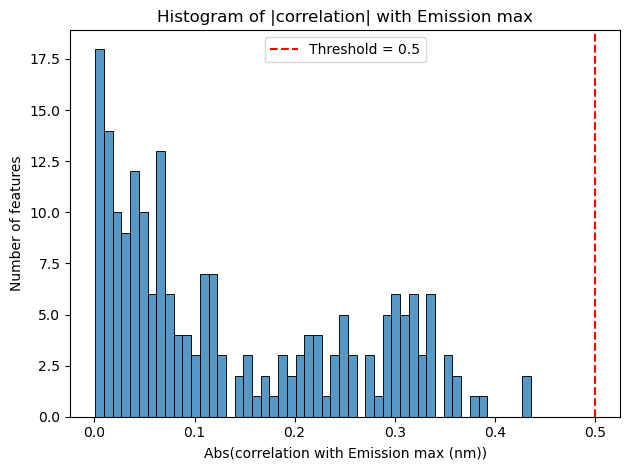

In [6]:
# 相関係数の計算（数値列のみ）- 目的変数1
dataset_train_num = dataset_train.select_dtypes(include="number")
corr_coef = dataset_train_num.corr()

target_col = TARGET_COLS[0]
corr_abs = corr_coef[target_col].drop(target_col).abs()

sns.histplot(corr_abs, bins=50)

plt.xlabel(f"Abs(correlation with {target_col})")
plt.ylabel("Number of features")
plt.title(f"Histogram of |correlation| with {target_col}")
plt.axvline(x=0.5, color="red", linestyle="--", label="Threshold = 0.5")
plt.legend()
plt.tight_layout()
plt.show()

### 記述子との相関の絶対値（Quantum yield / PLQY）


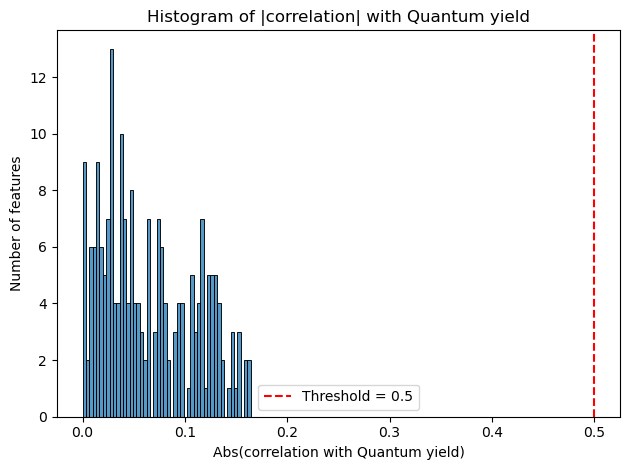

In [7]:
# 相関行列は上セルと同じ。セル単体実行用にここでも再計算する。- 目的変数2
if len(TARGET_COLS) >= 2:
    dataset_train_num = dataset_train.select_dtypes(include="number")
    corr_coef = dataset_train_num.corr()

    target_col = TARGET_COLS[1]
    corr_abs = corr_coef[target_col].drop(target_col).abs()

    sns.histplot(corr_abs, bins=50)

    plt.xlabel(f"Abs(correlation with {target_col})")
    plt.ylabel("Number of features")
    plt.title(f"Histogram of |correlation| with {target_col}")
    plt.axvline(x=0.5, color="red", linestyle="--", label="Threshold = 0.5")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("目的変数が1つのみのため、スキップ")

- 両方の目的変数において強い線形相関のある記述子は無かった

## PCA

記述子を主成分に射影する。以下では **同じ PC 座標** を、目的変数で色分けして見る。


### PCA プロット（Emission max）

In [8]:
# 目的変数と説明変数（記述子のみ）
y_targets = {col: dataset_train[col] for col in TARGET_COLS}
X = dataset_train.drop(columns=TARGET_COLS)

print("目的変数:")
for col, y in y_targets.items():
    print(f"  {col}: {y.shape}")
print(f"説明変数: {X.shape}")

((13132,), (13132,), (13132, 206))

In [9]:
# オートスケーリング
autoscaled_X = (X - X.mean()) / X.std()

In [10]:
# PCA
pca = PCA()
pca.fit(autoscaled_X)

# loading、各説明変数がその主成分に対してどれだけ寄与しているか
loading = pd.DataFrame(pca.components_.T, index=X.columns, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# score、変換後の座標
score = pd.DataFrame(pca.transform(autoscaled_X), index=X.index, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# 寄与率
cont_ratio = pd.DataFrame(pca.explained_variance_ratio_)
# 累積寄与率
cum_cont_ratio = cont_ratio.cumsum()
# 結合
cont_cumcont_ratio = pd.concat([cont_ratio, cum_cont_ratio], axis=1)
cont_cumcont_ratio.columns = ['contribution_ratio', 'cumulative_contribution_ratio']
cont_cumcont_ratio.index = [f'PC{i+1}' for i in cont_cumcont_ratio.index]

cont_cumcont_ratio.head(20)

,contribution_ratio,cumulative_contribution_ratio
PC1,0.194559,0.194559
PC2,0.083404,0.277963
PC3,0.045069,0.323032
PC4,0.034495,0.357527
PC5,0.031082,0.388609
PC6,0.025920,0.414529
PC7,0.025242,0.439771
PC8,0.022802,0.462573
PC9,0.019602,0.482174
PC10,0.019474,0.501649


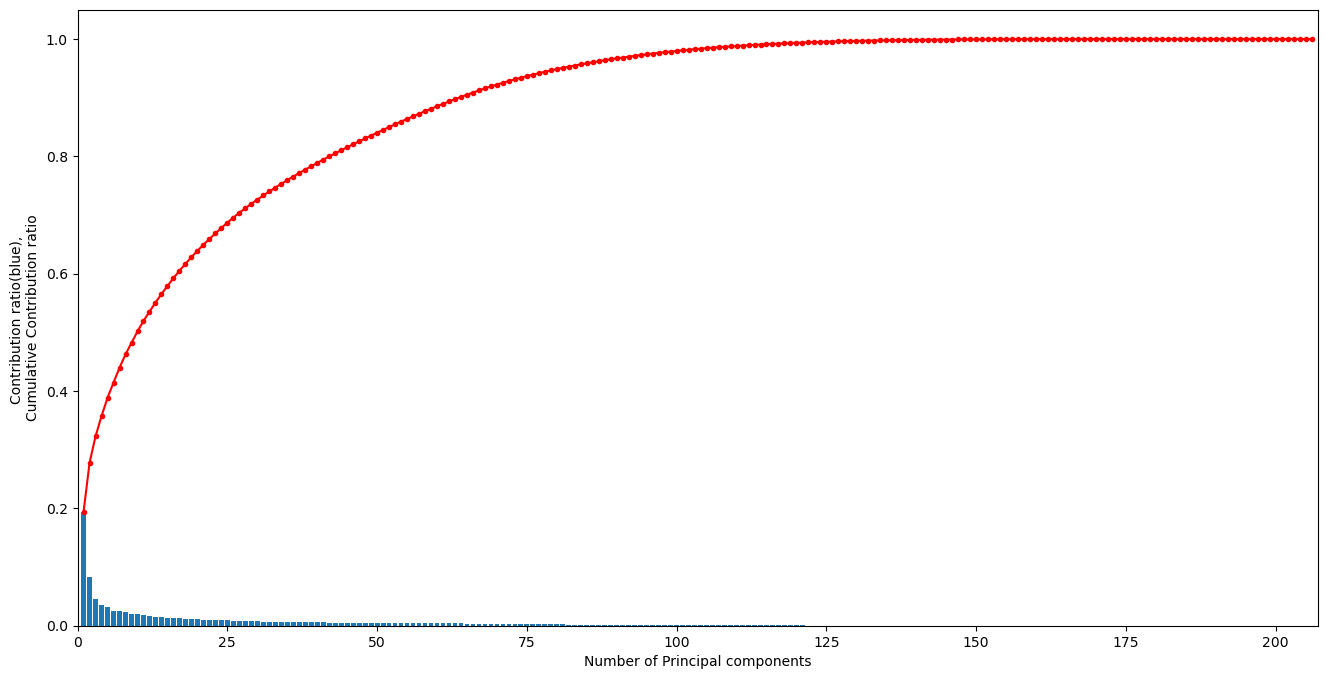

In [11]:
# 寄与率を折れ線で、累積寄与率を棒で可視化
x_axis = range(1, cont_cumcont_ratio.shape[0]+1)

# 図のサイズ
plt.figure(figsize=(16, 8))

# 棒グラフ
plt.bar(x_axis, cont_cumcont_ratio.iloc[:, 0], align='center')
# 折れ線
plt.plot(x_axis, cont_cumcont_ratio.iloc[:, 1], 'r.-')

plt.xlabel('Number of Principal components')
plt.ylabel('Contribution ratio(blue), \nCumulative Contribution ratio')
plt.xlim(0, cont_cumcont_ratio.shape[0]+1)

plt.show()

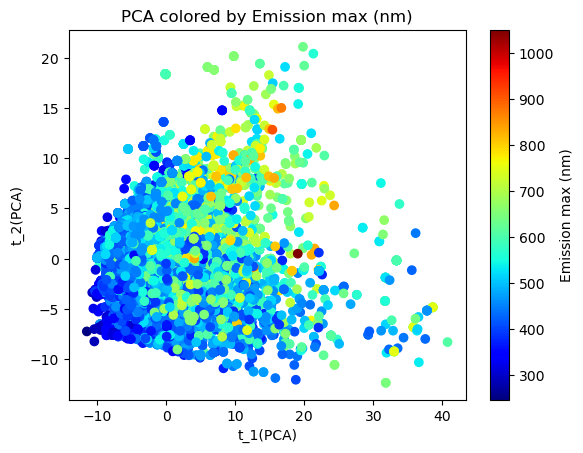

In [12]:
# 第 1・第 2 主成分（目的変数1で色付け）
plt.scatter(score.iloc[:, 0], score.iloc[:, 1], c=y_targets[TARGET_COLS[0]], cmap=plt.get_cmap('jet'))
plt.colorbar(label=TARGET_COLS[0])

plt.xlabel('t_1(PCA)')
plt.ylabel('t_2(PCA)')
plt.title(f"PCA colored by {TARGET_COLS[0]}")

plt.show()

### PCA プロット（Quantum yield / PLQY）

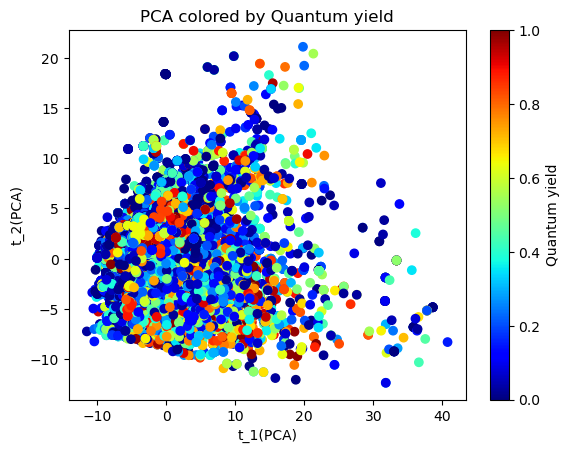

In [13]:
# 第 1・第 2 主成分（目的変数2で色付け）
if len(TARGET_COLS) >= 2:
    plt.scatter(score.iloc[:, 0], score.iloc[:, 1], c=y_targets[TARGET_COLS[1]], cmap=plt.get_cmap('jet'))
    plt.colorbar(label=TARGET_COLS[1])

    plt.xlabel('t_1(PCA)')
    plt.ylabel('t_2(PCA)')
    plt.title(f"PCA colored by {TARGET_COLS[1]}")

    plt.show()
else:
    print("目的変数が1つのみのため、スキップ")

## t-SNE

埋め込みは記述子のみから **1 回** 計算し、以下で Emission / PLQY を切り替えて色付けする。


In [14]:
def k3n_error(x_1, x_2, k):
    """
    k-nearest neighbor normalized error (k3n-error)

    金子先生の手法、可視化する前のサンプル間のユークリッド距離と、可視化後のサンプル間のユークリッド距離に基づく方法

    サンプルの近接関係は多次元空間⇔2次元平面で保持されているか？ということで、細かく分けると、

    1. 多次元空間において近いサンプル同士は、2次元平面においても近いか？
    2. 2次元平面において近いサンプル同士は、多次元空間においても近いか？

    k3n_errorは1と2を同時に評価する、2つとも近ければよい。
    サンプル同士が近いほど、k3n_errorは小さくなる

    k3n-error = k3n-Z-error + k3n-X-error

    Parameters
    ----------
    x_1: numpy.array or pandas.DataFrame
    x_2: numpy.array or pandas.DataFrame
    k: int
        The numbers of neighbor

    Returns
    -------
    k3n_error : float
        k3n-Z-error or k3n-X-error
    """
    x_1 = np.array(x_1)
    x_2 = np.array(x_2)

    x_1_distance = cdist(x_1, x_1)
    x_1_sorted_indexes = np.argsort(x_1_distance, axis=1)
    x_2_distance = cdist(x_2, x_2)

    for i in range(x_2.shape[0]):
        _replace_zero_with_the_smallest_positive_values(x_2_distance[i, :])

    identity_matrix = np.eye(len(x_1_distance), dtype=bool)
    knn_distance_in_x_1 = np.sort(x_2_distance[:, x_1_sorted_indexes[:, 1:k + 1]][identity_matrix])
    knn_distance_in_x_2 = np.sort(x_2_distance)[:, 1:k + 1]

    sum_k3n_error = (
            (knn_distance_in_x_1 - knn_distance_in_x_2) / knn_distance_in_x_2
    ).sum()
    return sum_k3n_error / x_1.shape[0] / k

def _replace_zero_with_the_smallest_positive_values(arr):
    """
    Replace zeros in array with the smallest positive values.

    Parameters
    ----------
    arr: numpy.array
    """
    arr[arr == 0] = np.min(arr[arr != 0])

In [15]:
# k(近傍数)は全データ行数から決める（最終 t-SNE 用の参考値）
n_samples = autoscaled_X.shape[0]
k_in_k3n_error = min(30, max(5, int(np.sqrt(n_samples))))  # 5〜30

# --- 重さ対策（元実装は「全件 TSNE × 20回」＋ k3n の cdist が O(n²) でメモリも膨らむ）---
# k3n で perplexity を選ぶときだけ、ランダム部分集合で近似する（次セル以降の本番 t-SNE は全件のまま）。
RNG_TSNE = np.random.default_rng(0)
TSNE_SEARCH_MAX_SAMPLES = 2000  # 増やすほど重い・メモリ大（必要なら 1500 などに下げる）
n_search = min(TSNE_SEARCH_MAX_SAMPLES, n_samples)
idx = RNG_TSNE.choice(n_samples, size=n_search, replace=False)
X_search = np.asarray(autoscaled_X.iloc[idx])

# perplexity は sklearn の制約 perplexity < n_samples を満たすよう上限をかける
_perp_cap = max(5, (n_search - 1) // 3)
_base = np.array([5, 15, 30, 50, min(80, _perp_cap)], dtype=int)
candidates_of_perplexity = np.unique(np.clip(_base, 5, _perp_cap))

# k3n は探索用サンプル数に合わせた k（大きすぎると計算も重い）
k_search = min(k_in_k3n_error, max(3, n_search // 100))

k3n_errors = []

for perplexity in candidates_of_perplexity:
    t = TSNE(
        perplexity=int(perplexity),
        n_components=2,
        init="pca",
        random_state=10,
        max_iter=350,
    ).fit_transform(X_search)
    scaled_t = (t - t.mean(axis=0)) / t.std(axis=0, ddof=1)
    k3n_errors.append(
        k3n_error(X_search, scaled_t, k_search)
        + k3n_error(scaled_t, X_search, k_search)
    )

optimal_perplexity = int(candidates_of_perplexity[int(np.argmin(k3n_errors))])

print(f"全サンプル数: {n_samples} / k3n 探索に使用したサンプル数: {n_search}")
print(f"k3n 探索で使用する k（近傍数）: {k_search}（全データ用の k 参考値: {k_in_k3n_error}）")
print(f"最適 perplexity（部分集合上の近似）: {optimal_perplexity}")

c:\Users\kawan\miniforge3\envs\chem_win\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


全サンプル数: 13132 / k3n 探索に使用したサンプル数: 2000
k3n 探索で使用する k（近傍数）: 20（全データ用の k 参考値: 30）
最適 perplexity（部分集合上の近似）: 80


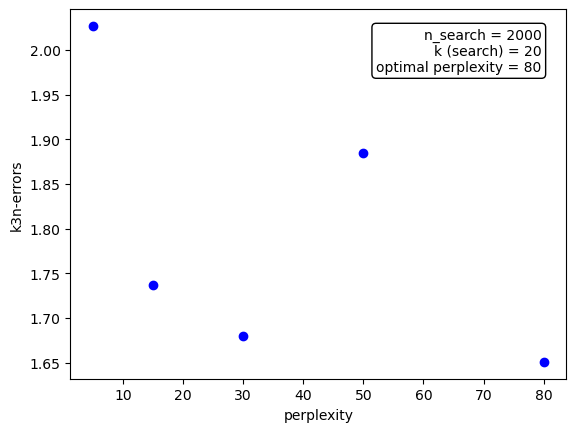

In [16]:
# 可視化（k3n は部分集合上で計算した誤差）
plt.scatter(candidates_of_perplexity, k3n_errors, c='blue')

# 右上に注釈（k は探索用 k_search。全データ参考値は k_in_k3n_error）
text_str = (
    f'n_search = {n_search}\n'
    f'k (search) = {k_search}\n'
    f'optimal perplexity = {optimal_perplexity}'
)

plt.text(0.95, 0.95, text_str,
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'))

plt.xlabel('perplexity')
plt.ylabel('k3n-errors')
plt.show()

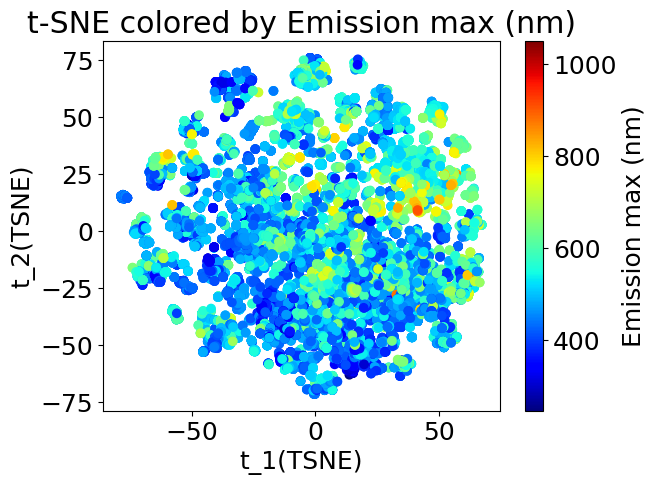

In [17]:
# t-SNE（1 回だけ fit）→ 目的変数1で色付け
_tsne_kw = dict(
    perplexity=int(optimal_perplexity),
    n_components=2,
    init="pca",
    random_state=10,
    max_iter=750,
)
try:
    t = TSNE(**_tsne_kw, n_jobs=-1).fit_transform(autoscaled_X)
except TypeError:
    t = TSNE(**_tsne_kw).fit_transform(autoscaled_X)

t = pd.DataFrame(t, index=X.index, columns=['t_1', 't_2'])

plt.rcParams['font.size'] = 18
plt.scatter(t.iloc[:, 0], t.iloc[:, 1], c=y_targets[TARGET_COLS[0]], cmap=plt.get_cmap('jet'))
plt.colorbar(label=TARGET_COLS[0])

plt.xlabel('t_1(TSNE)')
plt.ylabel('t_2(TSNE)')
plt.title(f"t-SNE colored by {TARGET_COLS[0]}")
plt.show()

### t-SNE プロット（色: Quantum yield / PLQY）


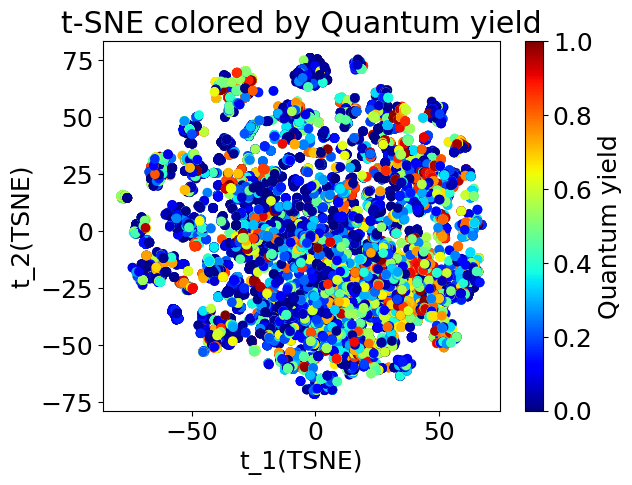

In [18]:
# 同じ埋め込み座標 t を目的変数2で色付け
if len(TARGET_COLS) >= 2:
    plt.rcParams['font.size'] = 18
    plt.scatter(t.iloc[:, 0], t.iloc[:, 1], c=y_targets[TARGET_COLS[1]], cmap=plt.get_cmap('jet'))
    plt.colorbar(label=TARGET_COLS[1])

    plt.xlabel('t_1(TSNE)')
    plt.ylabel('t_2(TSNE)')
    plt.title(f"t-SNE colored by {TARGET_COLS[1]}")
    plt.show()
else:
    print("目的変数が1つのみのため、スキップ")